# Credit Risk Scoring Model — Data Exploration
### McMillin Analytics

**Objective:** Build a classification model that predicts loan defaults using Lending Club data, applying the same credit analysis principles used in commercial underwriting to a consumer lending dataset.

**Why this matters:** Traditional credit scoring relies on rigid cutoffs. A well-built ML model can capture non-linear relationships between borrower characteristics and default probability — essentially doing what an experienced credit analyst does intuitively, but at scale.

---

## Data Source

**Lending Club Loan Data** — [Kaggle](https://www.kaggle.com/datasets/wordsforthewise/lending-club)  
~2.2 million loans issued between 2007–2018 with 150+ features including borrower financials, loan terms, and repayment outcomes.

**Setup:** Download the dataset from Kaggle and place `accepted_2007_to_2018Q4.csv` in the `data/raw/` directory.

---

## 1. Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Environment ready.')

Environment ready.


In [3]:
# Load the dataset
# NOTE: This is a large file (~1.7GB). low_memory=False prevents mixed type warnings.
df_raw = pd.read_csv('../data/raw/accepted_2007_to_2018Q4.csv', low_memory=False)

print(f'Dataset shape: {df_raw.shape[0]:,} loans x {df_raw.shape[1]} features')
print(f'Date range: {df_raw["issue_d"].dropna().min()} to {df_raw["issue_d"].dropna().max()}')

Dataset shape: 2,260,701 loans x 151 features
Date range: Apr-2008 to Sep-2018


In [4]:
# Quick look at the structure
df_raw.head(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,...,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.00,3600.00,3600.00,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.00,24700.00,24700.00,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.00,20000.00,20000.00,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_raw.info(verbose=True, show_counts=True)

---
## 2. Define the Target Variable

Before anything else, we need to clearly define what we're predicting. In credit underwriting, the key question is: **will this borrower repay?**

The `loan_status` field gives us the outcome. We need to map it to a binary target:
- **0 (Performing):** Fully Paid, Current
- **1 (Default):** Charged Off, Default
- **Exclude:** Loans still in repayment (Current, In Grace Period, Late) — we can't use these because the outcome is unknown

This mirrors how we'd approach it in loan review: you can only assess underwriting quality on loans that have reached a terminal state.

In [5]:
# Examine loan status distribution
print('Loan Status Distribution:')
print('=' * 50)
status_counts = df_raw['loan_status'].value_counts()
status_pcts = df_raw['loan_status'].value_counts(normalize=True) * 100

for status in status_counts.index:
    print(f'{status:.<40} {status_counts[status]:>10,}  ({status_pcts[status]:.1f}%)')

Loan Status Distribution:
Fully Paid..............................  1,076,751  (47.6%)
Current.................................    878,317  (38.9%)
Charged Off.............................    268,559  (11.9%)
Late (31-120 days)......................     21,467  (0.9%)
In Grace Period.........................      8,436  (0.4%)
Late (16-30 days).......................      4,349  (0.2%)
Does not meet the credit policy. Status:Fully Paid      1,988  (0.1%)
Does not meet the credit policy. Status:Charged Off        761  (0.0%)
Default.................................         40  (0.0%)


In [6]:
# Define target mapping
# Only keep loans with terminal outcomes — exclude loans still in repayment
terminal_statuses = {
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1
}

# Filter to terminal loans only
df = df_raw[df_raw['loan_status'].isin(terminal_statuses.keys())].copy()
df['default'] = df['loan_status'].map(terminal_statuses)

print(f'Loans with terminal outcomes: {len(df):,} ({len(df)/len(df_raw)*100:.1f}% of total)')
print(f'\nDefault rate: {df["default"].mean()*100:.1f}%')
print(f'  Performing: {(df["default"]==0).sum():,}')
print(f'  Defaulted:  {(df["default"]==1).sum():,}')

Loans with terminal outcomes: 1,345,350 (59.5% of total)

Default rate: 20.0%
  Performing: 1,076,751
  Defaulted:  268,599


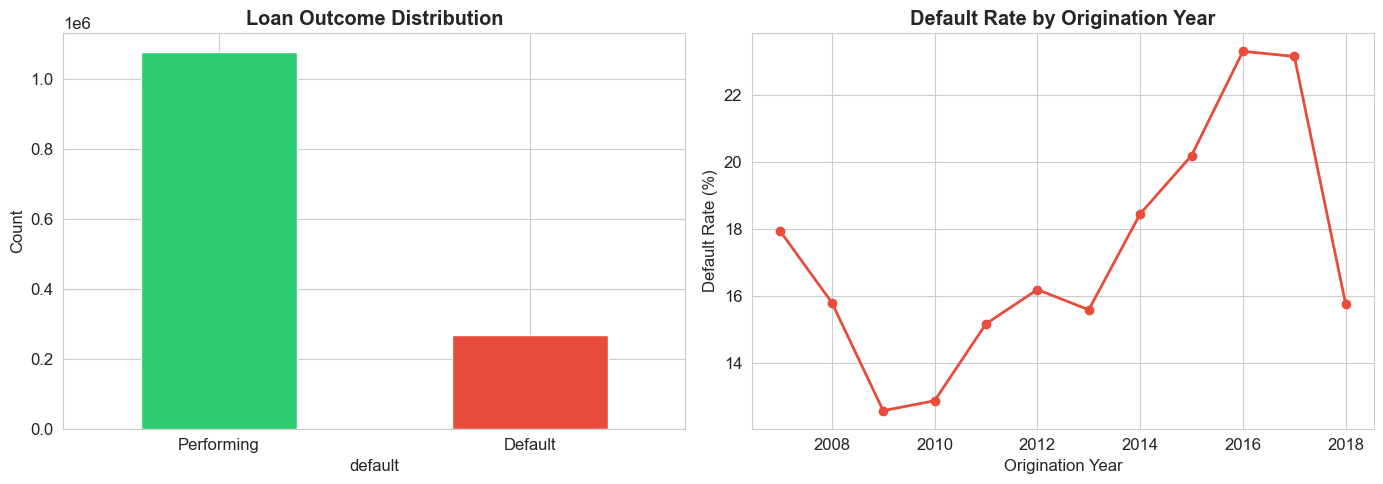


💡 Credit Insight: Default rates by vintage year tell a story about credit cycles.
   Loans originated in 2007-2008 likely show elevated defaults (financial crisis),
   while post-crisis vintages may show tighter underwriting standards.


In [7]:
# Visualize the class balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']
df['default'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Loan Outcome Distribution', fontweight='bold')
axes[0].set_xticklabels(['Performing', 'Default'], rotation=0)
axes[0].set_ylabel('Count')

# Default rate over time
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['issue_year'] = df['issue_d'].dt.year
yearly_default = df.groupby('issue_year')['default'].mean() * 100
yearly_default.plot(kind='line', ax=axes[1], marker='o', color='#e74c3c', linewidth=2)
axes[1].set_title('Default Rate by Origination Year', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xlabel('Origination Year')

plt.tight_layout()
plt.savefig('../results/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Credit Insight: Default rates by vintage year tell a story about credit cycles.')
print('   Loans originated in 2007-2008 likely show elevated defaults (financial crisis),') 
print('   while post-crisis vintages may show tighter underwriting standards.')

---
## 3. Feature Assessment

With 150 columns, we need to be strategic. We'll categorize features into groups that mirror how a credit analyst would evaluate a borrower — similar to the 5 C's framework:

| Credit Factor | Lending Club Proxy Features |
|---|---|
| **Capacity** (ability to repay) | `annual_inc`, `dti`, `emp_length` |
| **Character** (willingness to repay) | `fico_range_high`, `delinq_2yrs`, `inq_last_6mths`, `pub_rec` |
| **Capital** (net worth / skin in the game) | `home_ownership`, `revol_bal`, `total_acc` |
| **Conditions** (loan terms / macro) | `loan_amnt`, `int_rate`, `term`, `purpose` |
| **Collateral** | N/A for unsecured consumer loans |

We also need to identify and drop features that would cause **data leakage** — information that wouldn't be available at the time of underwriting.

In [8]:
# Assess missing values — critical for deciding what to keep
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('missing_pct', ascending=False)

print('Features with >50% missing (likely candidates for dropping):')
print('=' * 60)
high_missing = missing[missing['missing_pct'] > 50]
for idx, row in high_missing.iterrows():
    print(f'  {idx:.<45} {row["missing_pct"]:>5.1f}%')

print(f'\nTotal features with >50% missing: {len(high_missing)}')
print(f'Total features with 0% missing: {(missing["missing_pct"] == 0).sum()}')

Features with >50% missing (likely candidates for dropping):
  member_id.................................... 100.0%
  next_pymnt_d................................. 100.0%
  orig_projected_additional_accrued_interest...  99.7%
  hardship_type................................  99.6%
  hardship_status..............................  99.6%
  deferral_term................................  99.6%
  hardship_amount..............................  99.6%
  hardship_start_date..........................  99.6%
  hardship_end_date............................  99.6%
  payment_plan_start_date......................  99.6%
  hardship_length..............................  99.6%
  hardship_dpd.................................  99.6%
  hardship_loan_status.........................  99.6%
  hardship_payoff_balance_amount...............  99.6%
  hardship_last_payment_amount.................  99.6%
  hardship_reason..............................  99.6%
  sec_app_mths_since_last_major_derog..........  99.5%
  se

In [9]:
# Identify and remove DATA LEAKAGE features
# These contain information about loan PERFORMANCE — not available at origination

leakage_features = [
    # Payment behavior (only known after origination)
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'last_credit_pull_d', 'last_fico_range_high',
    'last_fico_range_low', 'next_pymnt_d',
    
    # Post-origination status
    'loan_status',  # This IS the target, encoded as 'default'
    'pymnt_plan', 'hardship_flag', 'debt_settlement_flag',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    
    # Hardship program details (post-origination)
    'hardship_type', 'hardship_reason', 'hardship_status',
    'hardship_start_date', 'hardship_end_date', 'hardship_length',
    'hardship_dpd', 'hardship_loan_status', 'hardship_amount',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'payment_plan_start_date', 'orig_projected_additional_accrued_interest',
    
    # Identifiers (no predictive value)
    'id', 'member_id', 'url', 'desc', 'title',
    'policy_code',  # All same value
]

# Only drop columns that actually exist in the dataframe
cols_to_drop = [col for col in leakage_features if col in df.columns]
df = df.drop(columns=cols_to_drop)

print(f'Dropped {len(cols_to_drop)} leakage/ID features')
print(f'Remaining features: {df.shape[1]}')

Dropped 43 leakage/ID features
Remaining features: 110


In [10]:
# Drop features with excessive missing values (>40% missing)
missing_threshold = 0.40
missing_pcts = df.isnull().mean()
high_missing_cols = missing_pcts[missing_pcts > missing_threshold].index.tolist()

print(f'Dropping {len(high_missing_cols)} features with >{missing_threshold*100:.0f}% missing values:')
for col in high_missing_cols:
    print(f'  {col}: {missing_pcts[col]*100:.1f}% missing')

df = df.drop(columns=high_missing_cols)
print(f'\nRemaining features: {df.shape[1]}')

Dropping 37 features with >40% missing values:
  mths_since_last_delinq: 50.5% missing
  mths_since_last_record: 83.0% missing
  mths_since_last_major_derog: 73.7% missing
  annual_inc_joint: 98.1% missing
  dti_joint: 98.1% missing
  verification_status_joint: 98.1% missing
  open_acc_6m: 60.0% missing
  open_act_il: 60.0% missing
  open_il_12m: 60.0% missing
  open_il_24m: 60.0% missing
  mths_since_rcnt_il: 61.1% missing
  total_bal_il: 60.0% missing
  il_util: 65.4% missing
  open_rv_12m: 60.0% missing
  open_rv_24m: 60.0% missing
  max_bal_bc: 60.0% missing
  all_util: 60.0% missing
  inq_fi: 60.0% missing
  total_cu_tl: 60.0% missing
  inq_last_12m: 60.0% missing
  mths_since_recent_bc_dlq: 76.3% missing
  mths_since_recent_revol_delinq: 66.6% missing
  revol_bal_joint: 98.6% missing
  sec_app_fico_range_low: 98.6% missing
  sec_app_fico_range_high: 98.6% missing
  sec_app_earliest_cr_line: 98.6% missing
  sec_app_inq_last_6mths: 98.6% missing
  sec_app_mort_acc: 98.6% missing
  

---
## 4. Explore Key Credit Risk Drivers

Now let's examine the features that matter most from an underwriting perspective. These are the variables a credit analyst would focus on when evaluating a borrower.

### 4a. Capacity — Can the borrower afford the payments?

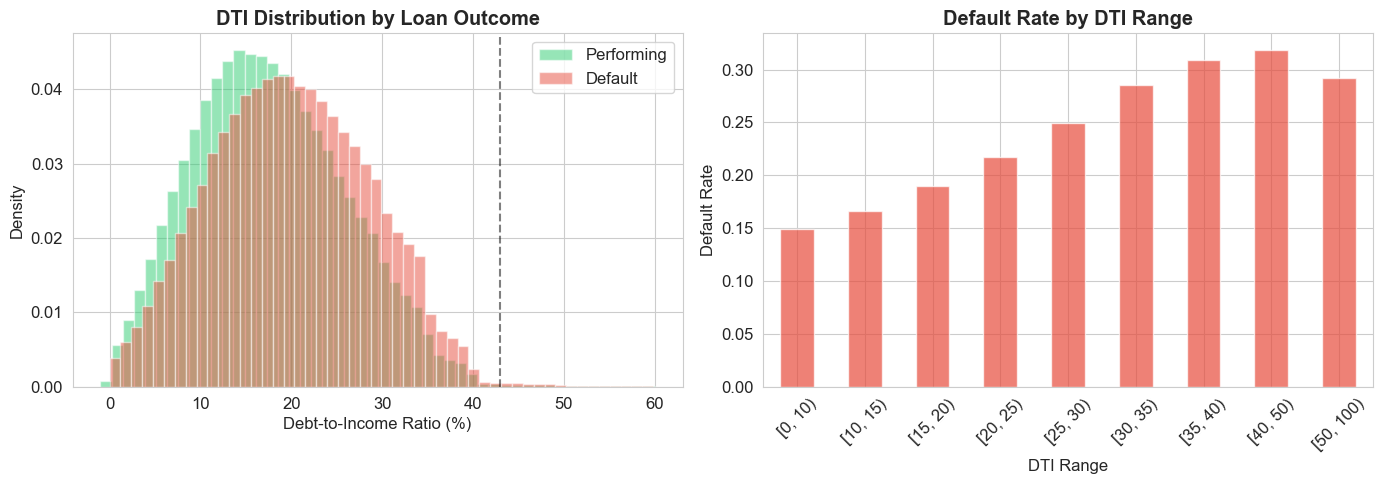

DTI Summary by Outcome:
         mean   50%   75%
default                  
0       17.80 17.10 23.40
1       20.20 19.80 26.30

💡 Credit Insight: In commercial underwriting, DTI above 40% is typically a red flag.
   The QM threshold of 43% exists for a reason — watch for a default rate inflection.


In [11]:
# Debt-to-Income Ratio (DTI) — the single most important capacity metric
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by default status
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['default'] == label]['dti'].dropna()
    subset = subset[subset <= 60]  # Cap for visualization
    axes[0].hist(subset, bins=50, alpha=0.5, color=color, 
                 label='Performing' if label == 0 else 'Default', density=True)

axes[0].set_title('DTI Distribution by Loan Outcome', fontweight='bold')
axes[0].set_xlabel('Debt-to-Income Ratio (%)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].axvline(x=43, color='black', linestyle='--', alpha=0.5, label='QM Threshold (43%)')

# Default rate by DTI bucket
df['dti_bucket'] = pd.cut(df['dti'], bins=[0, 10, 15, 20, 25, 30, 35, 40, 50, 100], 
                          right=False)
dti_default = df.groupby('dti_bucket', observed=True)['default'].agg(['mean', 'count'])
dti_default['mean'].plot(kind='bar', ax=axes[1], color='#e74c3c', alpha=0.7)
axes[1].set_title('Default Rate by DTI Range', fontweight='bold')
axes[1].set_ylabel('Default Rate')
axes[1].set_xlabel('DTI Range')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/02_dti_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print('DTI Summary by Outcome:')
print(df.groupby('default')['dti'].describe()[['mean', '50%', '75%']].round(1))
print('\n💡 Credit Insight: In commercial underwriting, DTI above 40% is typically a red flag.')
print('   The QM threshold of 43% exists for a reason — watch for a default rate inflection.')

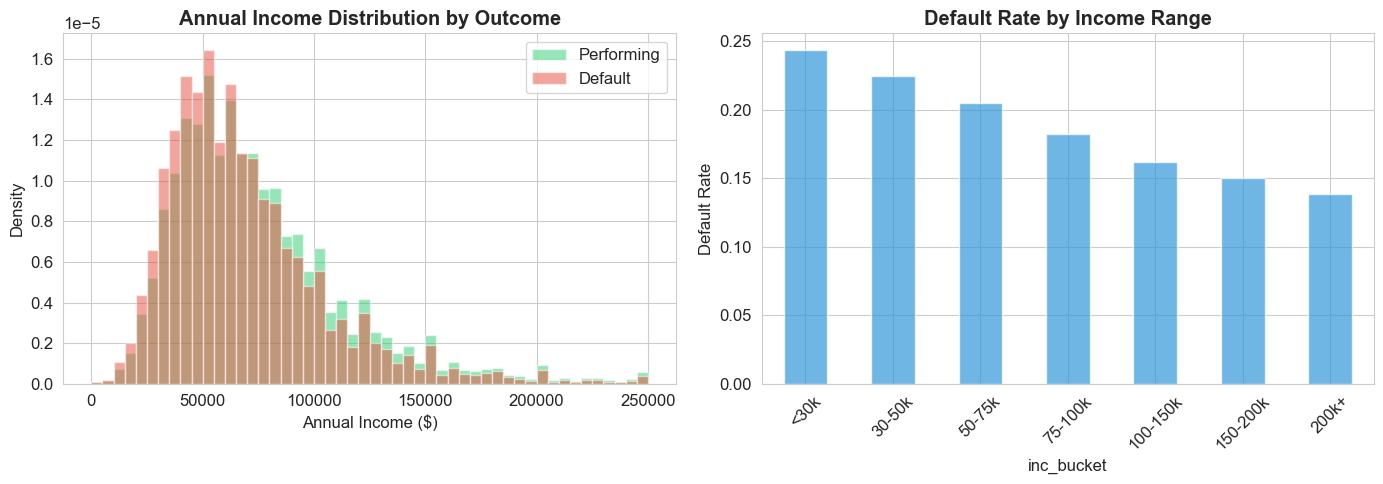

In [12]:
# Annual Income
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cap at $250k for visualization (long right tail)
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['default'] == label]['annual_inc'].dropna()
    subset = subset[subset <= 250000]
    axes[0].hist(subset, bins=50, alpha=0.5, color=color,
                 label='Performing' if label == 0 else 'Default', density=True)

axes[0].set_title('Annual Income Distribution by Outcome', fontweight='bold')
axes[0].set_xlabel('Annual Income ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Default rate by income bucket
df['inc_bucket'] = pd.cut(df['annual_inc'], 
                          bins=[0, 30000, 50000, 75000, 100000, 150000, 200000, 1e9],
                          labels=['<30k', '30-50k', '50-75k', '75-100k', '100-150k', '150-200k', '200k+'])
inc_default = df.groupby('inc_bucket', observed=True)['default'].agg(['mean', 'count'])
inc_default['mean'].plot(kind='bar', ax=axes[1], color='#3498db', alpha=0.7)
axes[1].set_title('Default Rate by Income Range', fontweight='bold')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/03_income_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4b. Character — What does the borrower's credit history tell us?

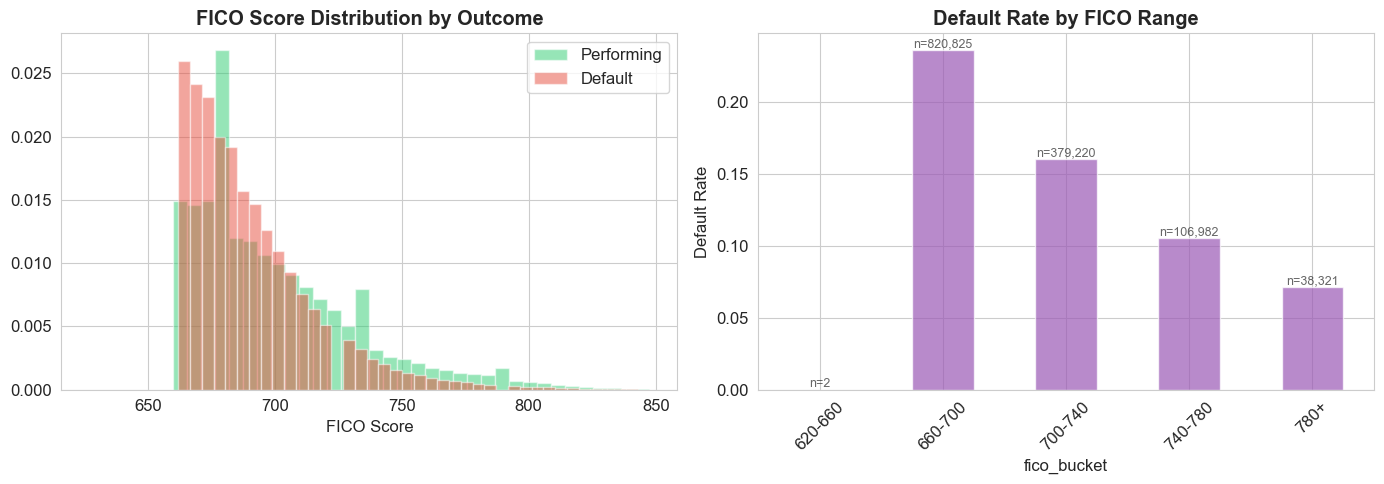

FICO Summary by Outcome:
          mean    50%   std
default                    
0       700.00 692.00 33.00
1       690.00 682.00 26.00

💡 Credit Insight: FICO below 660 is typically subprime territory.
   Watch for the inflection point — does default risk increase linearly or exponentially?


In [13]:
# FICO Score — the headline credit quality metric
# Lending Club provides a range; we'll use the midpoint
df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['default'] == label]['fico_score'].dropna()
    axes[0].hist(subset, bins=40, alpha=0.5, color=color,
                 label='Performing' if label == 0 else 'Default', density=True)

axes[0].set_title('FICO Score Distribution by Outcome', fontweight='bold')
axes[0].set_xlabel('FICO Score')
axes[0].legend()

# Default rate by FICO bucket
df['fico_bucket'] = pd.cut(df['fico_score'], 
                           bins=[0, 620, 660, 700, 740, 780, 850],
                           labels=['<620', '620-660', '660-700', '700-740', '740-780', '780+'])
fico_default = df.groupby('fico_bucket', observed=True)['default'].agg(['mean', 'count'])
fico_default['mean'].plot(kind='bar', ax=axes[1], color='#9b59b6', alpha=0.7)
axes[1].set_title('Default Rate by FICO Range', fontweight='bold')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=45)

# Add count annotations
for i, (idx, row) in enumerate(fico_default.iterrows()):
    axes[1].annotate(f'n={row["count"]:,.0f}', 
                     xy=(i, row['mean']), 
                     ha='center', va='bottom', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.savefig('../results/04_fico_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('FICO Summary by Outcome:')
print(df.groupby('default')['fico_score'].describe()[['mean', '50%', 'std']].round(0))
print('\n💡 Credit Insight: FICO below 660 is typically subprime territory.')
print('   Watch for the inflection point — does default risk increase linearly or exponentially?')

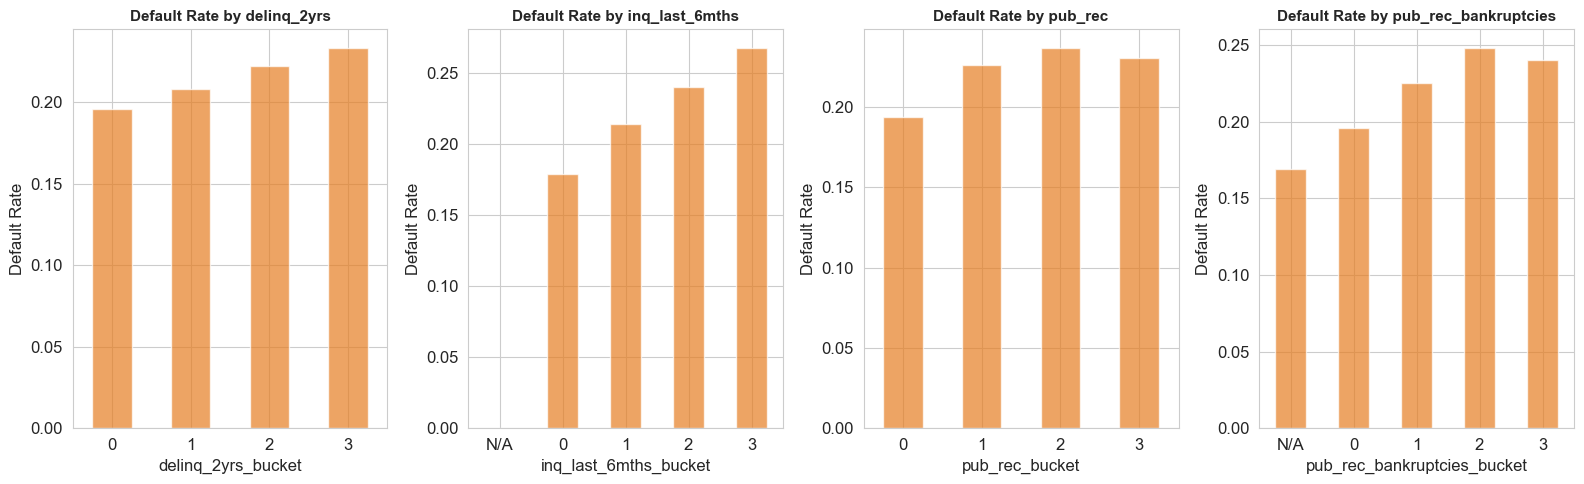

In [15]:
# Derogatory credit history markers
derog_features = ['delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'pub_rec_bankruptcies']
derog_available = [f for f in derog_features if f in df.columns]

fig, axes = plt.subplots(1, len(derog_available), figsize=(4*len(derog_available), 5))
if len(derog_available) == 1:
    axes = [axes]

for ax, feature in zip(axes, derog_available):
    # Bucket: 0, 1, 2, 3+
    df[f'{feature}_bucket'] = df[feature].clip(upper=3).fillna(-1)
    default_by_bucket = df.groupby(f'{feature}_bucket')['default'].mean()
    default_by_bucket.plot(kind='bar', ax=ax, color='#e67e22', alpha=0.7)
    ax.set_title(f'Default Rate by {feature}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Default Rate')
    ax.tick_params(axis='x', rotation=0)
    tick_labels = [str(int(x)) if x >= 0 else 'N/A' for x in sorted(df[f'{feature}_bucket'].unique())]
    ax.set_xticklabels(tick_labels)

plt.tight_layout()
plt.savefig('../results/05_derogatory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4c. Conditions — What are the loan terms?

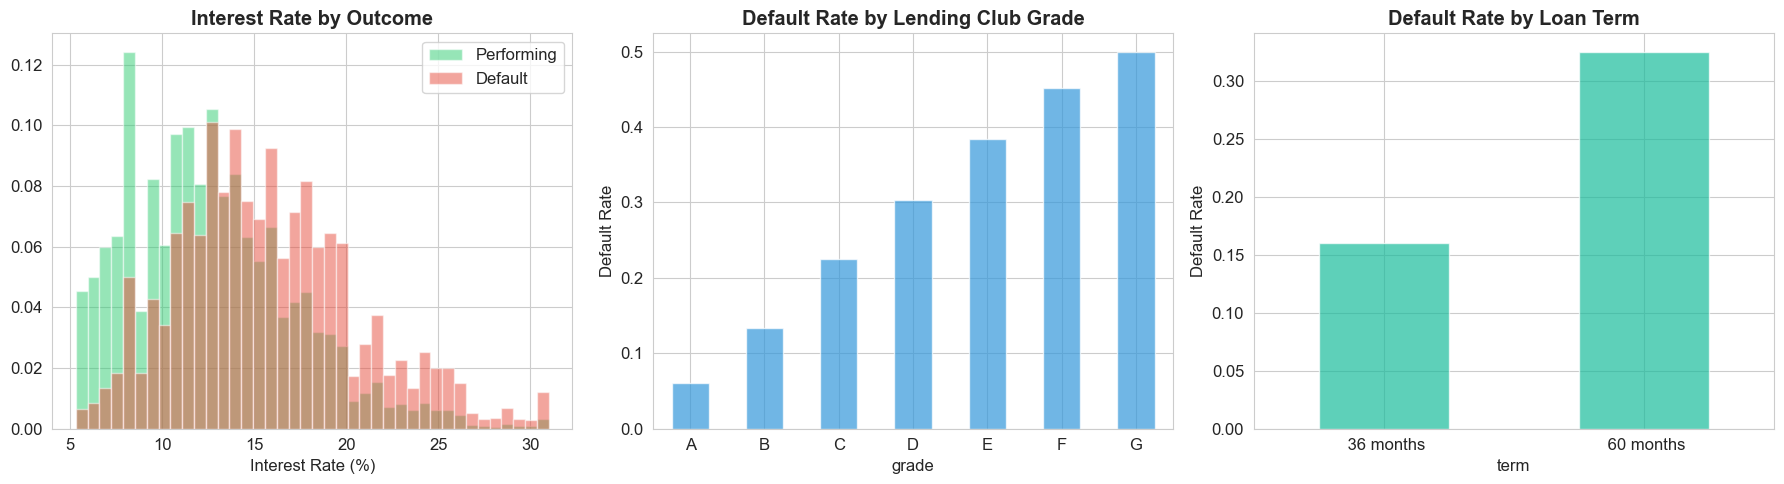

💡 Credit Insight: Higher rates reflect higher risk pricing, but also create higher
   debt service burden — a feedback loop. 60-month loans carry more risk than 36-month
   loans, consistent with commercial lending where longer tenor = higher risk.


In [16]:
# Interest Rate — a proxy for Lending Club's own risk assessment
# Clean interest rate (may be stored as string with %)
if df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.rstrip('%').astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Interest rate distribution
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['default'] == label]['int_rate'].dropna()
    axes[0].hist(subset, bins=40, alpha=0.5, color=color,
                 label='Performing' if label == 0 else 'Default', density=True)
axes[0].set_title('Interest Rate by Outcome', fontweight='bold')
axes[0].set_xlabel('Interest Rate (%)')
axes[0].legend()

# Default rate by grade
grade_default = df.groupby('grade')['default'].mean().sort_index()
grade_default.plot(kind='bar', ax=axes[1], color='#3498db', alpha=0.7)
axes[1].set_title('Default Rate by Lending Club Grade', fontweight='bold')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=0)

# Term comparison
term_default = df.groupby('term')['default'].mean()
term_default.plot(kind='bar', ax=axes[2], color='#1abc9c', alpha=0.7)
axes[2].set_title('Default Rate by Loan Term', fontweight='bold')
axes[2].set_ylabel('Default Rate')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/06_loan_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Credit Insight: Higher rates reflect higher risk pricing, but also create higher')
print('   debt service burden — a feedback loop. 60-month loans carry more risk than 36-month')
print('   loans, consistent with commercial lending where longer tenor = higher risk.')

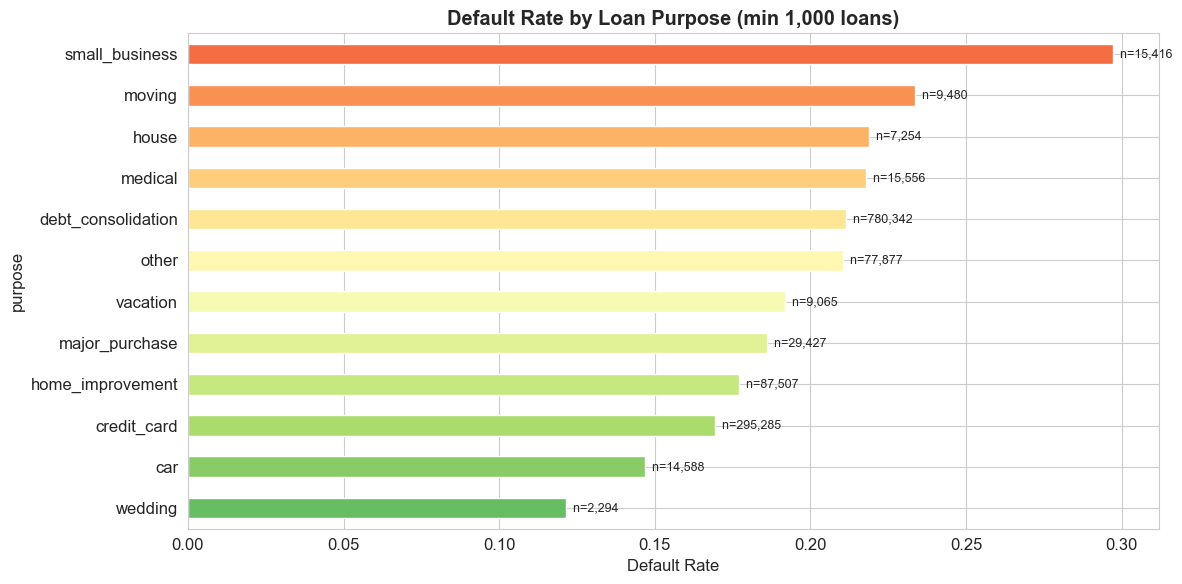

💡 Credit Insight: "Small business" loans showing higher default rates is expected —
   these borrowers are using personal credit to fund business operations,
   indicating potentially strained cash flow and higher risk.


In [17]:
# Loan Purpose analysis
fig, ax = plt.subplots(figsize=(12, 6))

purpose_stats = df.groupby('purpose')['default'].agg(['mean', 'count']).sort_values('mean', ascending=True)
purpose_stats = purpose_stats[purpose_stats['count'] >= 1000]  # Filter for statistical significance

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(purpose_stats)))
purpose_stats['mean'].plot(kind='barh', ax=ax, color=colors)
ax.set_title('Default Rate by Loan Purpose (min 1,000 loans)', fontweight='bold')
ax.set_xlabel('Default Rate')

# Add count labels
for i, (idx, row) in enumerate(purpose_stats.iterrows()):
    ax.annotate(f'  n={row["count"]:,.0f}', xy=(row['mean'], i), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/07_purpose_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Credit Insight: "Small business" loans showing higher default rates is expected —')
print('   these borrowers are using personal credit to fund business operations,')
print('   indicating potentially strained cash flow and higher risk.')

### 4d. Capital & Leverage

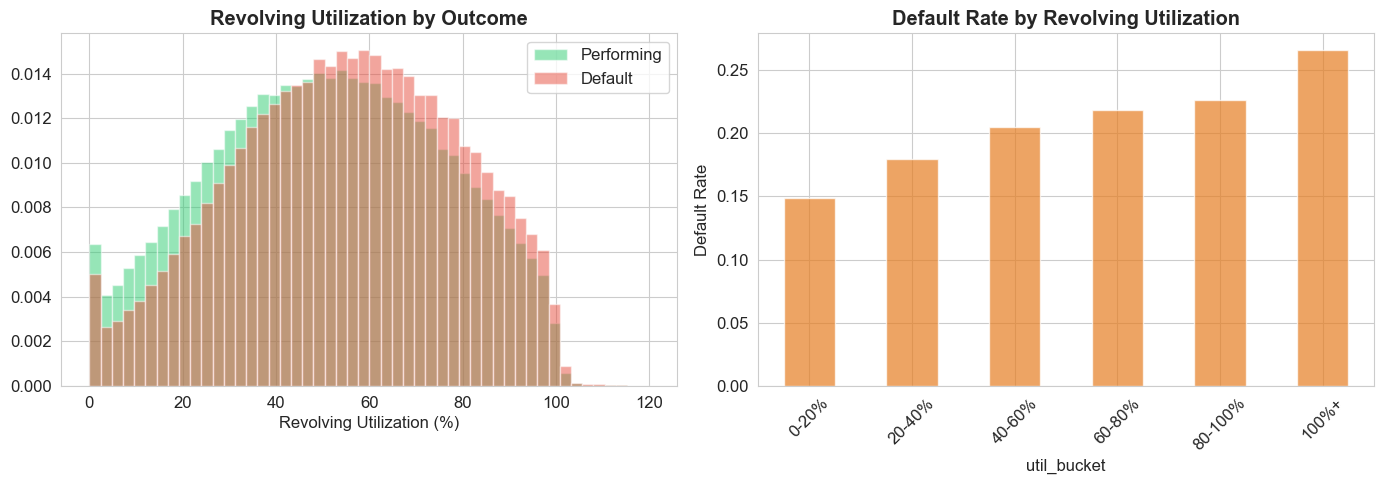

💡 Credit Insight: Revolving utilization above 80% is a classic stress indicator.
   In commercial lending, line utilization trending toward limits signals liquidity
   pressure — the consumer equivalent is maxing out credit cards.


In [18]:
# Revolving utilization — how much of available credit is being used
if df['revol_util'].dtype == 'object':
    df['revol_util'] = df['revol_util'].str.rstrip('%').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['default'] == label]['revol_util'].dropna()
    subset = subset[subset <= 120]  # Cap for vis
    axes[0].hist(subset, bins=50, alpha=0.5, color=color,
                 label='Performing' if label == 0 else 'Default', density=True)
axes[0].set_title('Revolving Utilization by Outcome', fontweight='bold')
axes[0].set_xlabel('Revolving Utilization (%)')
axes[0].legend()

# Default rate by utilization bucket
df['util_bucket'] = pd.cut(df['revol_util'], 
                           bins=[0, 20, 40, 60, 80, 100, 200],
                           labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%', '100%+'])
util_default = df.groupby('util_bucket', observed=True)['default'].mean()
util_default.plot(kind='bar', ax=axes[1], color='#e67e22', alpha=0.7)
axes[1].set_title('Default Rate by Revolving Utilization', fontweight='bold')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/08_utilization_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Credit Insight: Revolving utilization above 80% is a classic stress indicator.')
print('   In commercial lending, line utilization trending toward limits signals liquidity')
print('   pressure — the consumer equivalent is maxing out credit cards.')

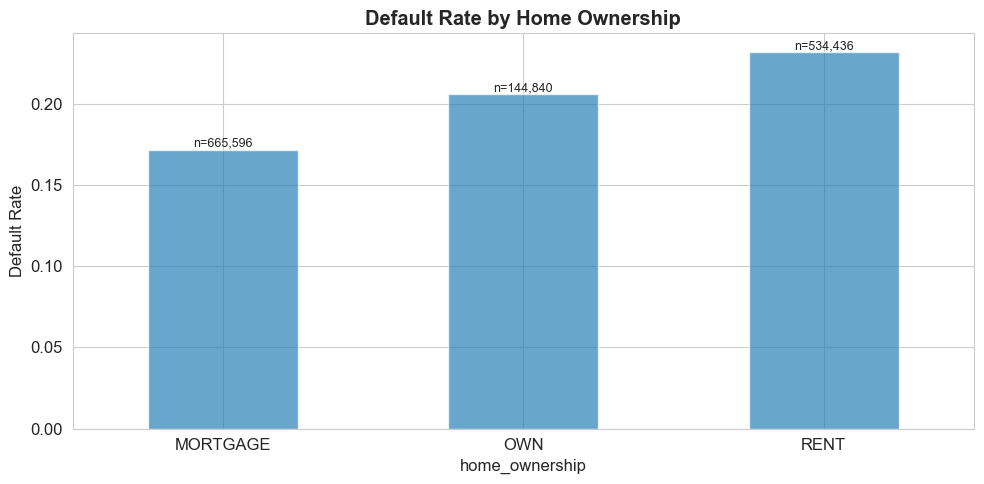

In [19]:
# Home ownership — a proxy for stability and capital
fig, ax = plt.subplots(figsize=(10, 5))

home_stats = df.groupby('home_ownership')['default'].agg(['mean', 'count'])
home_stats = home_stats[home_stats['count'] >= 1000].sort_values('mean')

home_stats['mean'].plot(kind='bar', ax=ax, color='#2980b9', alpha=0.7)
ax.set_title('Default Rate by Home Ownership', fontweight='bold')
ax.set_ylabel('Default Rate')
ax.tick_params(axis='x', rotation=0)

for i, (idx, row) in enumerate(home_stats.iterrows()):
    ax.annotate(f'n={row["count"]:,.0f}', xy=(i, row['mean']), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/09_homeownership_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Correlation Analysis

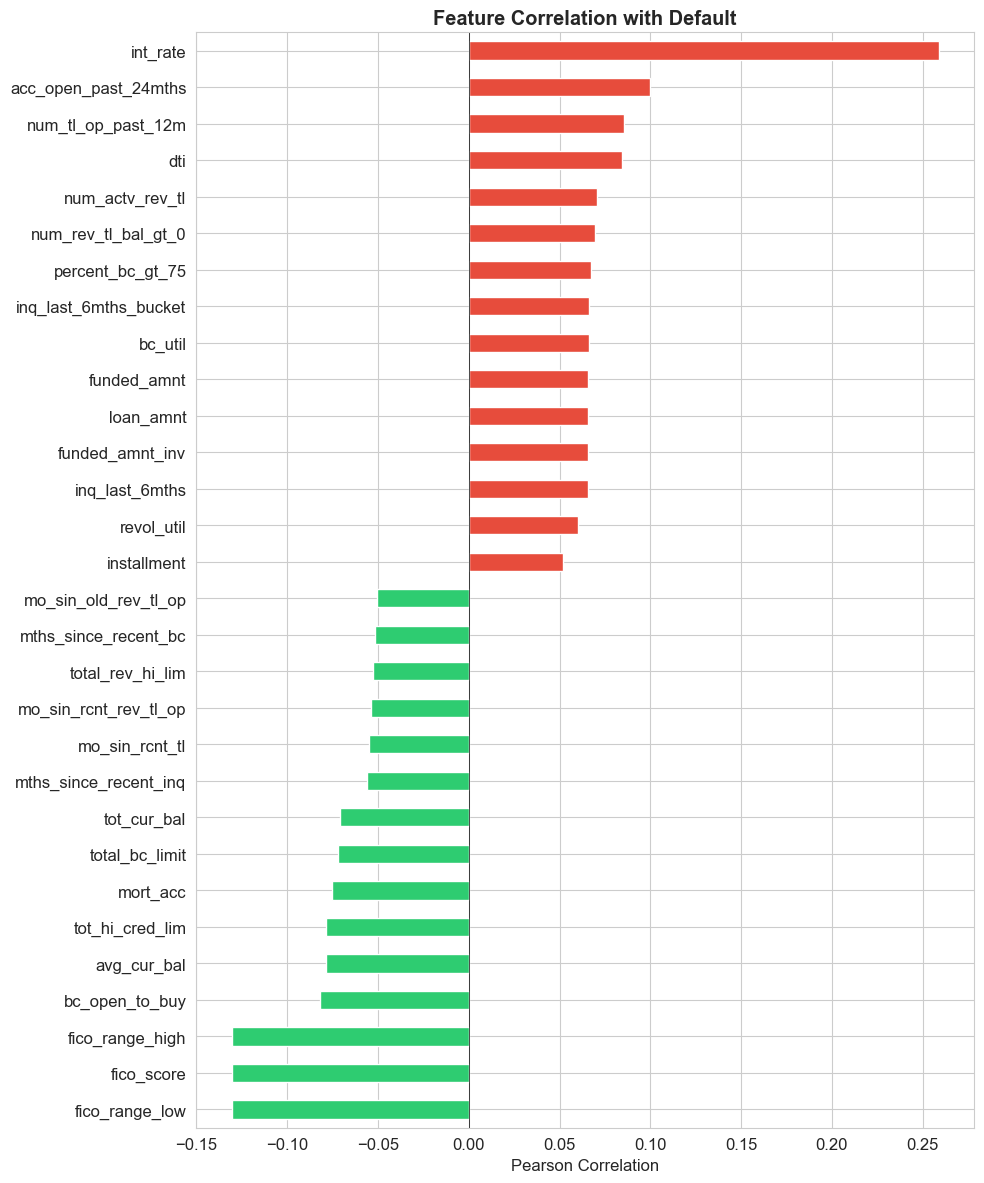


Top 10 features most positively correlated with default (higher = more defaults):
  funded_amnt............................. +0.0657
  bc_util................................. +0.0661
  inq_last_6mths_bucket................... +0.0663
  percent_bc_gt_75........................ +0.0674
  num_rev_tl_bal_gt_0..................... +0.0694
  num_actv_rev_tl......................... +0.0708
  dti..................................... +0.0845
  num_tl_op_past_12m...................... +0.0856
  acc_open_past_24mths.................... +0.0999
  int_rate................................ +0.2588

Top 10 features most negatively correlated with default (higher = fewer defaults):
  fico_range_low.......................... -0.1307
  fico_score.............................. -0.1307
  fico_range_high......................... -0.1307
  bc_open_to_buy.......................... -0.0820
  avg_cur_bal............................. -0.0789
  tot_hi_cred_lim......................... -0.0785
  mort_acc.......

In [20]:
# Correlation with target for all numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['default'].drop('default').sort_values()

fig, ax = plt.subplots(figsize=(10, 12))

# Show top and bottom 20 correlations
top_bottom = pd.concat([correlations.head(15), correlations.tail(15)])
colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in top_bottom.values]
top_bottom.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Correlation with Default', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../results/10_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features most positively correlated with default (higher = more defaults):')
for feat, corr in correlations.tail(10).items():
    print(f'  {feat:.<40} {corr:>+.4f}')

print('\nTop 10 features most negatively correlated with default (higher = fewer defaults):')
for feat, corr in correlations.head(10).items():
    print(f'  {feat:.<40} {corr:>+.4f}')

---
## 6. Key Observations & Next Steps

### Preliminary Findings

Document your observations here after running the analysis. Template:

**Class Balance:**
- Default rate of ~X% — moderate imbalance. Will need to address in modeling (SMOTE, class weights, or threshold tuning).

**Strongest Risk Indicators (from credit analyst perspective):**
- DTI: [Assuming the 50--100% Debt to Income decrease is explained by survivorship bias and strong conditions related to those transactions. Above 20% DTI exhibits a strong inflection point where risk of default grows at an increasing rate. ]
- FICO: [Lending club did not provide loans to subprime (below 660 FICO has sample size of 2; There is a large increase in default rate as FICO score falls (~ 24% default rate on 660-700 bucket vs 7% for 780+ bucket)']
- Interest Rate / Grade: [Higher interest rate required in order to justify credit risk and additonal stress of increased debt service requirements; the Lending Club grading model has done well at grading Default risk]
- Revolving Utilization: [The higher levered an individual the higher the default risk as customer becomes strained and capacity dries up]
- Loan Purpose: [small business is mush higher risk of default relative to any other loan type; using loans to fund operating cash flow as it is potentially strained]

**Data Quality Issues:**
- [The default rates by vintage did not seem intuitive as 2007 - 2008/2009 vintages were better performing than later loans ; potentialy credit standars being loosened]
  
### Next Steps (Notebook 02 — Feature Engineering)
1. Select final feature set based on this analysis
2. Create derived features (utilization ratio, payment-to-income, credit history length)
3. Encode categorical variables
4. Handle remaining missing values
5. Address class imbalance
6. Train/test split

In [22]:
# Drop temporary bucket columns created during exploration
bucket_cols = [col for col in df.columns if col.endswith('_bucket')]
df = df.drop(columns=bucket_cols)

# Save the cleaned exploration dataset for the next notebook
df.to_parquet('../data/processed/01_explored_data.parquet', index=False)
print(f'Saved cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'File: ../data/processed/01_explored_data.parquet')

Saved cleaned dataset: 1,345,350 rows x 74 columns
File: ../data/processed/01_explored_data.parquet
